<img src="../images/practicum_ai_logo.png" alt="Practicum AI Logo" align="right" width="250">

---

# 03: The Attention Architect
### How Transformers Learn to Read DNA

**Dr. Aris** sits down at his terminal with one goal: build a model that can distinguish a functional promoter from a non-functional sequence — using only the DNA itself.

This is harder than it sounds. A promoter is 57 base pairs long. The entire UCI Promoter dataset is 106 sequences. Any model that needs large data to work is dead on arrival. The question is whether pretrained DNA language models carry enough biological knowledge in their weights to solve the problem from a standing start.

We will find out — systematically. Starting from a baseline trained entirely from scratch, we progress through three pretrained foundation models, each with a different approach to tokenizing DNA. By the end, we'll have a clear picture of where the value in pretraining comes from.

---
### 🎯 Learning Objectives
1. **Promoter biology** — understand what a promoter does and why the TATA box matters
2. **Tokenization strategies** — compare 6-mer, single-nucleotide, and BPE tokenization
3. **Feature extraction** — use frozen pretrained backbones as off-the-shelf feature detectors
4. **Attention visualization** — inspect what biological patterns the models actually learn
5. **Model comparison** — benchmark four models on identical data splits

### 📚 Models We'll Cover
1. **Baseline Transformer** — from scratch; establishes the performance floor
2. **DNABERT (6-mer, 86M)** — the pioneering DNA BERT, pretrained on the human genome
3. **Nucleotide Transformer (500M)** — large-scale multi-species pretraining
4. **DNABERT-2 (BPE, 117M)** — learned tokenization, cross-species pretraining, ALiBi positions

### 📐 Series Position

| NB | Architecture | Key novelty |
|---|---|---|
| **NB03** | **Transformer** | **Attention, k-mer vs BPE tokenization** |
| NB04 | Mamba / SSM | Linear scaling, selective memory |
| NB05 | Hyena | Sub-quadratic, 1M bp context |
| NB06 | All three | Variant effect prediction |
| NB07 | DNABERT + HyenaDNA | Fine-tuning strategies |

## 0. Environment Setup

Uncomment the install line the first time you run this notebook on a new environment. On HiPerGator (the `biotm3` conda env), all dependencies are pre-installed.

> **GPU memory:** This notebook loads up to three large models. Shut down any idle kernels from other notebooks before running to avoid OOM errors. DNABERT needs ~400 MB VRAM; NT-500M needs ~2 GB; DNABERT-2 needs ~500 MB.

In [1]:
# !pip install transformers datasets torch pandas requests scikit-learn matplotlib seaborn

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


## 1. Hardware Detection

Dr. Aris's first principle: *always know your compute before choosing a model*. This cell auto-detects GPU (HiPerGator L4), Apple Silicon, or CPU and sets the device for all subsequent model loads.

> **HiPerGator users:** You're running on an NVIDIA L4 GPU with 22 GB VRAM — optimal for this notebook.

In [2]:
def get_device():
    if torch.cuda.is_available():
        print("🚀 HiPerGator Detected: Utilizing CUDA")
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   CUDA Version: {torch.version.cuda}")
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        print("💻 Apple Silicon Detected: Utilizing MPS")
        return torch.device("mps")
    else:
        print("☁️ CPU Mode — some cells may be slow")
        return torch.device("cpu")

device = get_device()
torch.manual_seed(42)
np.random.seed(42)
print(f"\n✅ Device ready: {device.type.upper()}")

🚀 HiPerGator Detected: Utilizing CUDA
   GPU: NVIDIA L4
   CUDA Version: 12.8

✅ Device ready: CUDA


## 2. The Dataset: UCI Promoter Sequences

### What is a Promoter?
A **promoter** is a short DNA sequence upstream of a gene that signals "start transcription here." It is the biological equivalent of a capital letter at the beginning of a sentence — without it, the gene cannot be expressed. Mutations in promoters are directly linked to cancer, metabolic disorders, and developmental diseases.

### The TATA Box
Many promoters contain the **TATA box** (`TATAAA`), located approximately 25–30 base pairs before the transcription start site. This is one of the most conserved and well-studied regulatory elements in eukaryotic genetics. If a model has learned anything about promoter biology, it should be sensitive to the TATA box.

### Our Task
Given a **57 bp DNA sequence**, predict whether it is a functional promoter (+) or not (−). The UCI Promoter Gene Sequence dataset contains exactly 106 sequences: 53 promoters and 53 non-promoters. This intentionally tiny dataset stress-tests whether pretrained representations are useful when labeled data is scarce — a common real-world scenario.

### Why 57 bp?
This is roughly the footprint of the minimal core promoter: the TATA box region plus flanking sequence on both sides. It is short enough to fit within any model's context window (even DNABERT's 512 token limit) but long enough to contain real biological signal.

In [3]:
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/molecular-biology/promoter-gene-sequences/promoters.data"

print("📥 Fetching UCI Promoter Dataset...")
response = requests.get(url)

lines = [line.strip().split(',') for line in response.text.strip().split('\n') if line.strip()]

processed_data = []
for line in lines:
    label = 1 if line[0].strip() == '+' else 0
    sequence = line[2].replace('\t', '').replace(' ', '').upper()
    processed_data.append({"sequence": sequence, "label": label})

df = pd.DataFrame(processed_data)

print(f"✅ Loaded {len(df)} sequences")
print(f"   Promoters (+):     {(df['label']==1).sum()}")
print(f"   Non-Promoters (-): {(df['label']==0).sum()}")
print(f"\nExample promoter sequence:")
print(df[df['label']==1].iloc[0]['sequence'])

📥 Fetching UCI Promoter Dataset...
✅ Loaded 106 sequences
   Promoters (+):     53
   Non-Promoters (-): 53

Example promoter sequence:
TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT


🔬 TATA Box Analysis:
   Promoters with TATA:     25 / 53 (47.2%)
   Non-promoters with TATA: 4 / 53 (7.5%)


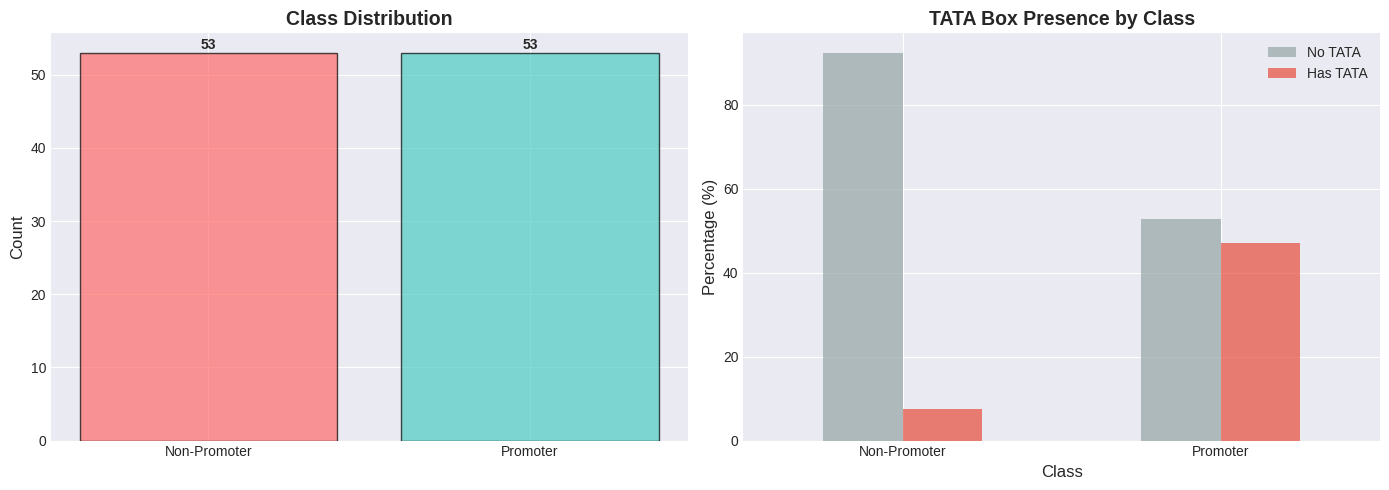


📊 Key Insight: TATA boxes are enriched in promoters — but 53% of promoters have NO TATA box.
   A model that only checks for TATA would miss more than half the positives.


In [4]:
# TATA box analysis
df['has_tata'] = df['sequence'].str.contains('TATA')

print("🔬 TATA Box Analysis:")
print(f"   Promoters with TATA:     {df[df['label']==1]['has_tata'].sum()} / {(df['label']==1).sum()} "
      f"({df[df['label']==1]['has_tata'].sum()/(df['label']==1).sum()*100:.1f}%)")
print(f"   Non-promoters with TATA: {df[df['label']==0]['has_tata'].sum()} / {(df['label']==0).sum()} "
      f"({df[df['label']==0]['has_tata'].sum()/(df['label']==0).sum()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['label'].value_counts()
axes[0].bar(['Non-Promoter', 'Promoter'], [class_counts[0], class_counts[1]],
            color=['#FF6B6B', '#4ECDC4'], edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
for i, count in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, count + 0.5, str(count), ha='center', fontweight='bold')

tata_data = pd.crosstab(df['label'], df['has_tata'], normalize='index') * 100
tata_data.plot(kind='bar', ax=axes[1], color=['#95a5a6', '#e74c3c'], alpha=0.7)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('TATA Box Presence by Class', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Non-Promoter', 'Promoter'], rotation=0)
axes[1].legend(['No TATA', 'Has TATA'])
plt.tight_layout()
plt.show()

print("\n📊 Key Insight: TATA boxes are enriched in promoters — but 53% of promoters have NO TATA box.")
print("   A model that only checks for TATA would miss more than half the positives.")

## 3. DNA Tokenization: The Foundation

*"The way you tokenize DNA fundamentally changes what patterns a model can see."* — Dr. Aris

Before loading any models, we need to understand the three tokenization strategies used across the field. Each makes a different trade-off:

| Strategy | Vocab size | Used by | Strength | Limitation |
|---|---|---|---|---|
| **Single nucleotide** | 4 | Nucleotide Transformer | Exact SNP resolution | All context built in deep layers |
| **6-mer sliding window** | 4,096 | DNABERT | Captures local motifs | Overlapping windows are redundant |
| **BPE (learned)** | ~4,096 | DNABERT-2 | Motif-aligned, adaptive | Requires multi-species pretraining |

The cell below demonstrates all three on the same sequence, so you can see exactly how each strategy segments the same biological text.

In [5]:
example_seq = df[df['label']==1].iloc[0]['sequence'][:30]

print("🧬 Example Sequence (30 bp):")
print(example_seq)
print("\n" + "="*60)

print("\n1️⃣  SINGLE NUCLEOTIDE (Nucleotide Transformer):")
single_tokens = list(example_seq)
print(f"   Tokens: {single_tokens[:15]}...")
print(f"   Vocabulary size: 4 | Sequence length: {len(single_tokens)} tokens")

print("\n2️⃣  6-MER SLIDING WINDOW (DNABERT):")
k = 6
kmers_6 = [example_seq[i:i+k] for i in range(len(example_seq)-k+1)]
print(f"   Tokens: {kmers_6[:7]}...")
print(f"   Vocabulary size: {4**k:,} | Sequence length: {len(kmers_6)} tokens")
print(f"   Note: 'TATAAA' is a single token — maps directly to the TATA box motif")

print("\n3️⃣  BPE TOKENIZATION (DNABERT-2 — learned from data):")
print(f"   Common motifs like TATAAA → single token")
print(f"   Rare / novel sequences → split into smaller subwords")
print(f"   Vocabulary size: ~4,096 (learned, not enumerated)")
print(f"   Advantage: Shorter sequences, no redundancy, handles mutations gracefully")

🧬 Example Sequence (30 bp):
TACTAGCAATACGCTTGCGTTCGGTGGTTA


1️⃣  SINGLE NUCLEOTIDE (Nucleotide Transformer):
   Tokens: ['T', 'A', 'C', 'T', 'A', 'G', 'C', 'A', 'A', 'T', 'A', 'C', 'G', 'C', 'T']...
   Vocabulary size: 4 | Sequence length: 30 tokens

2️⃣  6-MER SLIDING WINDOW (DNABERT):
   Tokens: ['TACTAG', 'ACTAGC', 'CTAGCA', 'TAGCAA', 'AGCAAT', 'GCAATA', 'CAATAC']...
   Vocabulary size: 4,096 | Sequence length: 25 tokens
   Note: 'TATAAA' is a single token — maps directly to the TATA box motif

3️⃣  BPE TOKENIZATION (DNABERT-2 — learned from data):
   Common motifs like TATAAA → single token
   Rare / novel sequences → split into smaller subwords
   Vocabulary size: ~4,096 (learned, not enumerated)
   Advantage: Shorter sequences, no redundancy, handles mutations gracefully


## 4. Data Preparation

We split the dataset **once here** and reuse the exact same split for every model in this notebook — and in NB04 through NB07. This ensures all accuracy numbers are directly comparable.

**Split strategy:** 70% train / 15% validation / 15% test, stratified by label. With 106 total sequences this gives us 74 training samples, 16 validation, and 16 test. Stratification ensures each split has a balanced 50/50 class ratio.

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print("📊 Data Split:")
print(f"   Training:   {len(train_df)} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"   Validation: {len(val_df)} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"   Test:       {len(test_df)} samples ({len(test_df)/len(df)*100:.1f}%)")

print("\nClass balance per split:")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    pos = (split['label'] == 1).sum()
    neg = (split['label'] == 0).sum()
    print(f"   {name:8s}: {pos} promoters, {neg} non-promoters")

BATCH_SIZE = 16 if device.type == "cuda" else 8
print(f"\n✅ Batch size: {BATCH_SIZE}")

📊 Data Split:
   Training:   74 samples (69.8%)
   Validation: 16 samples (15.1%)
   Test:       16 samples (15.1%)

Class balance per split:
   Train   : 37 promoters, 37 non-promoters
   Val     : 8 promoters, 8 non-promoters
   Test    : 8 promoters, 8 non-promoters

✅ Batch size: 16


## 5. Shared Training Utilities

These three functions underpin every model trained in this notebook. Using identical training infrastructure ensures the comparison is fair — we're measuring the models, not the training code.

- `train_epoch()` — one pass through the training set with gradient updates
- `evaluate()` — loss, accuracy, predictions, and probabilities on any split
- `train_model()` — full training loop with **early stopping** (patience = 3–5 epochs on validation loss) and **best-checkpoint saving** (based on validation accuracy)

Early stopping is especially important here: with only 74 training samples, models can memorize the training set quickly. Saving the best validation checkpoint gives us the weights at peak generalization, not peak memorization.

In [7]:
def train_epoch(model, dataloader, optimizer, device, use_amp=False):
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    for batch in tqdm(dataloader, desc="Training", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        optimizer.zero_grad()

        if use_amp:
            with torch.cuda.amp.autocast():
                outputs = model(input_ids, attention_mask, labels)
            scaler.scale(outputs.loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(input_ids, attention_mask, labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += outputs.loss.item()
        preds   = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(dataloader), correct / total


def evaluate(model, dataloader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids, attention_mask, labels)

            total_loss += outputs.loss.item()
            preds  = torch.argmax(outputs.logits, dim=1)
            probs  = torch.softmax(outputs.logits, dim=1)[:, 1]
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'loss': total_loss / len(dataloader),
        'accuracy': correct / total,
        'predictions': np.array(all_preds),
        'labels': np.array(all_labels),
        'probabilities': np.array(all_probs)
    }


def train_model(model, train_loader, val_loader, optimizer, num_epochs,
                save_path, device, use_amp=False, patience=3):
    best_val_acc, best_val_loss = 0, float('inf')
    patience_count = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}")
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, device, use_amp)
        val_results = evaluate(model, val_loader, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_results['loss'])
        history['val_acc'].append(val_results['accuracy'])

        print(f"    Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"    Val Loss:   {val_results['loss']:.4f} | Val Acc:   {val_results['accuracy']:.4f}")

        if val_results['accuracy'] > best_val_acc:
            best_val_acc = val_results['accuracy']
            torch.save(model.state_dict(), save_path)
            print(f"    ✅ New best saved ({best_val_acc:.4f})")

        if val_results['loss'] < best_val_loss:
            best_val_loss  = val_results['loss']
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n🛑 Early stopping at epoch {epoch+1}")
                break

        if device.type == "cuda":
            torch.cuda.empty_cache()

    return history

print("✅ Training utilities ready")

✅ Training utilities ready


## 6. Model Results Tracker

The `model_results` dictionary accumulates results from every model as we train them. The final comparison cell (Section 11) reads from this dictionary to produce the summary table and plots. If you skip a model section, its entry is simply absent from the comparison — no changes needed elsewhere.

In [8]:
model_results = {}
print("📊 Model comparison tracker initialised")

📊 Model comparison tracker initialised


## 7. Model 1: Baseline Transformer (From Scratch)

*"Before you reach for a pretrained model, know your floor."* — Dr. Aris

We build a small Transformer from random weights with a custom 3-mer tokenizer. This model has never seen a DNA sequence before. It must learn everything — what DNA looks like, what a promoter looks like, and how to distinguish the two — from exactly 74 labeled examples.

**Architecture:** 2 Transformer encoder layers, 4 attention heads, 128 hidden dimensions. 3-mer tokenizer with vocabulary size 64 ($4^3$). Total: ~800K parameters, all trained from scratch.

**Expected behavior:** The model will learn *something*, but without pretraining it has no prior knowledge of the human genome. Its performance defines our **floor** — if any pretrained model cannot beat this, something has gone wrong.

In [9]:
class SimpleKmerTokenizer:
    """3-mer sliding window tokenizer for DNA sequences."""

    def __init__(self, k=3):
        self.k = k
        from itertools import product
        bases = ['A', 'T', 'C', 'G']
        kmers = [''.join(p) for p in product(bases, repeat=k)]
        self.vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        for i, kmer in enumerate(kmers, start=3):
            self.vocab[kmer] = i
        self.vocab_size   = len(self.vocab)
        self.pad_token_id = 0

    def tokenize(self, sequence):
        return [sequence[i:i+self.k] for i in range(len(sequence)-self.k+1)]

    def encode(self, sequence, max_length=60):
        kmers = self.tokenize(sequence)
        ids = [self.vocab['[CLS]']] + [self.vocab.get(k, self.pad_token_id) for k in kmers]
        if len(ids) < max_length:
            ids += [self.pad_token_id] * (max_length - len(ids))
        return ids[:max_length]

    def __call__(self, sequence, max_length=60, return_tensors=None):
        ids  = self.encode(sequence, max_length)
        mask = [1 if i != self.pad_token_id else 0 for i in ids]
        if return_tensors == 'pt':
            return {'input_ids': torch.tensor([ids]), 'attention_mask': torch.tensor([mask])}
        return {'input_ids': ids, 'attention_mask': mask}


base_tokenizer = SimpleKmerTokenizer(k=3)
print(f"✅ 3-mer tokenizer | vocab size: {base_tokenizer.vocab_size}")

test_seq = "ATGCATGC"
print(f"   Test: '{test_seq}' → {base_tokenizer.tokenize(test_seq)}")

✅ 3-mer tokenizer | vocab size: 67
   Test: 'ATGCATGC' → ['ATG', 'TGC', 'GCA', 'CAT', 'ATG', 'TGC']


In [10]:
class PromoterDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=60):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq   = self.data.loc[idx, 'sequence']
        label = self.data.loc[idx, 'label']
        enc   = self.tokenizer(seq, max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(label, dtype=torch.long)
        }


base_train_loader = DataLoader(PromoterDataset(train_df, base_tokenizer),
                               batch_size=BATCH_SIZE, shuffle=True)
base_val_loader   = DataLoader(PromoterDataset(val_df,   base_tokenizer),
                               batch_size=BATCH_SIZE, shuffle=False)
base_test_loader  = DataLoader(PromoterDataset(test_df,  base_tokenizer),
                               batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Baseline dataloaders ready | batch size: {BATCH_SIZE}")

✅ Baseline dataloaders ready | batch size: 16


In [11]:
class SimpleTransformer(nn.Module):
    """Small transformer classifier for DNA sequences."""

    def __init__(self, vocab_size, hidden_size=128, num_layers=4, num_heads=4, num_labels=2):
        super().__init__()
        self.embedding     = nn.Embedding(vocab_size, hidden_size, padding_idx=0)
        self.pos_embedding = nn.Embedding(60, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, nhead=num_heads,
            dim_feedforward=hidden_size*4, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.dropout     = nn.Dropout(0.1)
        self.classifier  = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        x = self.embedding(input_ids)
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        x = x + self.pos_embedding(positions)
        mask = (attention_mask == 0) if attention_mask is not None else None
        x = self.transformer(x, src_key_padding_mask=mask)
        logits = self.classifier(self.dropout(x[:, 0, :]))
        loss   = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

        class Out:
            def __init__(self, loss, logits):
                self.loss = loss
                self.logits = logits
        return Out(loss, logits)


baseline_model = SimpleTransformer(vocab_size=base_tokenizer.vocab_size).to(device)
params_baseline = sum(p.numel() for p in baseline_model.parameters())
print(f"✅ Baseline Transformer | params: {params_baseline:,}")

✅ Baseline Transformer | params: 809,602


In [12]:
print("🚀 Training Baseline Transformer...\n")

optimizer = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3)
baseline_history = train_model(
    baseline_model, base_train_loader, base_val_loader,
    optimizer, num_epochs=15, save_path='baseline_best.pt',
    device=device, patience=4
)

baseline_model.load_state_dict(torch.load('baseline_best.pt'))
test_results_baseline = evaluate(baseline_model, base_test_loader, device)

print("\n" + "="*55)
print("BASELINE TRANSFORMER — TEST RESULTS")
print("="*55)
print(f"Test Accuracy: {test_results_baseline['accuracy']:.4f}")
print(classification_report(
    test_results_baseline['labels'],
    test_results_baseline['predictions'],
    target_names=['Non-Promoter', 'Promoter'], digits=4
))

model_results['Baseline Transformer'] = {
    'test_acc':     test_results_baseline['accuracy'],
    'test_results': test_results_baseline,
    'params':       params_baseline,
    'tokenization': '3-mer',
    'pretrained':   False,
    'color':        '#FF6B6B'
}

🚀 Training Baseline Transformer...

  Epoch 1/15


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 1.3325 | Train Acc: 0.4459
    Val Loss:   1.0674 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/15


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.1965 | Train Acc: 0.9324
    Val Loss:   0.8055 | Val Acc:   0.8125

🛑 Early stopping at epoch 8


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


BASELINE TRANSFORMER — TEST RESULTS
Test Accuracy: 0.5000
              precision    recall  f1-score   support

Non-Promoter     0.5000    0.2500    0.3333         8
    Promoter     0.5000    0.7500    0.6000         8

    accuracy                         0.5000        16
   macro avg     0.5000    0.5000    0.4667        16
weighted avg     0.5000    0.5000    0.4667        16



## 8. Model 2: DNABERT (6-mer Pretrained)

**What is DNABERT?**
Published by Ji et al. (2021, Bioinformatics), DNABERT was the first BERT-style model pretrained specifically on the human genome. It demonstrated that the masked language modeling objective — predict randomly hidden tokens from context — could teach a model the 'grammar' of DNA without any labeled data.

**Tokenization:** DNABERT uses **6-mer sliding windows**. Every 6-base window becomes one token from a vocabulary of 4,096. Crucially, the TATA box `TATAAA` is exactly one 6-mer token — the model can learn this signal in a single weight update rather than composing it from six steps.

**Pretraining:** MLM on the human reference genome GRCh38. Architecture: BERT-base — 12 layers, 768 hidden dimensions, 12 attention heads, **86M parameters**.

**Our strategy — Feature Extraction:**
We freeze the entire DNABERT backbone and train only a 2-layer linear classification head. With 74 training samples, this is the safest approach: we trust the pretrained representations to already encode promoter biology, and let the head learn how to read them.

In [13]:
from transformers import AutoTokenizer, AutoModel

DNABERT_NAME = "zhihan1996/DNA_bert_6"

print("🧬 Loading DNABERT-6...")
try:
    dnabert_tokenizer = AutoTokenizer.from_pretrained(DNABERT_NAME, trust_remote_code=True)
    dnabert_base      = AutoModel.from_pretrained(DNABERT_NAME, trust_remote_code=True)

    print(f"✅ DNABERT loaded")
    print(f"   Hidden size:      {dnabert_base.config.hidden_size}")
    print(f"   Transformer layers: {dnabert_base.config.num_hidden_layers}")
    print(f"   Attention heads:  {dnabert_base.config.num_attention_heads}")
    print(f"   Vocab size:       {dnabert_base.config.vocab_size:,}")
    dnabert_available = True

except Exception as e:
    print(f"⚠️  Could not load DNABERT: {e}")
    dnabert_available = False

🧬 Loading DNABERT-6...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DNABERT loaded
   Hidden size:      768
   Transformer layers: 12
   Attention heads:  12
   Vocab size:       4,101


### How DNABERT Tokenizes DNA

DNABERT requires sequences to be converted into **space-separated 6-mers** before tokenization — this is an unusual preprocessing step not needed by other models in this series.

The cell below demonstrates this transformation on a real promoter sequence from our dataset, and shows the actual token IDs the model receives. Compare the 6-mer boundaries to the TATA box position — does the motif fall cleanly within one token?

In [14]:
if dnabert_available:
    example_promoter = df[df['label']==1].iloc[0]['sequence']

    def seq_to_6mers(seq):
        """Convert raw DNA string to space-separated 6-mers."""
        return " ".join([seq[i:i+6] for i in range(len(seq) - 6 + 1)])

    formatted = seq_to_6mers(example_promoter)
    tokens    = dnabert_tokenizer.tokenize(formatted)
    ids       = dnabert_tokenizer.encode(formatted)

    print("🧬 Original sequence (57 bp):")
    print(f"   {example_promoter}\n")
    print("🔤 First 8 space-separated 6-mers:")
    print(f"   {' | '.join(formatted.split()[:8])}  ...\n")
    print(f"📌 Token IDs (first 10): {ids[:10]}")
    print(f"   Total tokens: {len(ids)}")
    print(f"\n💡 Notice: each 6-mer maps to a unique integer in DNABERT's 4,096-word vocabulary.")
    print(f"   If the sequence contains 'TATAAA', it becomes a single token ID.")

🧬 Original sequence (57 bp):
   TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT

🔤 First 8 space-separated 6-mers:
   TACTAG | ACTAGC | CTAGCA | TAGCAA | AGCAAT | GCAATA | CAATAC | AATACG  ...

📌 Token IDs (first 10): [2, 1176, 595, 2365, 1253, 902, 3593, 2071, 80, 307]
   Total tokens: 54

💡 Notice: each 6-mer maps to a unique integer in DNABERT's 4,096-word vocabulary.
   If the sequence contains 'TATAAA', it becomes a single token ID.


In [15]:
if dnabert_available:

    class DNABERTDataset(Dataset):
        """Formats sequences as space-separated 6-mers for DNABERT."""

        def __init__(self, dataframe, tokenizer, max_length=512):
            self.data      = dataframe.reset_index(drop=True)
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence']
            label = self.data.loc[idx, 'label']
            formatted = " ".join([seq[i:i+6] for i in range(len(seq) - 6 + 1)])
            enc = self.tokenizer(
                formatted,
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(label, dtype=torch.long)
            }

    db_train_loader = DataLoader(DNABERTDataset(train_df, dnabert_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=True)
    db_val_loader   = DataLoader(DNABERTDataset(val_df,   dnabert_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=False)
    db_test_loader  = DataLoader(DNABERTDataset(test_df,  dnabert_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=False)

    print(f"✅ DNABERT dataloaders ready | batch size: {BATCH_SIZE}")

✅ DNABERT dataloaders ready | batch size: 16


In [16]:
if dnabert_available:

    class DNABERTClassifier(nn.Module):
        """
        DNABERT backbone + linear classification head.
        The backbone is frozen — only the classifier head is trained.
        This 'feature extraction' approach works well for very small datasets.
        """

        def __init__(self, base_model, num_labels=2, freeze_backbone=True):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(base_model.config.hidden_size, num_labels)

            if freeze_backbone:
                for param in self.base_model.parameters():
                    param.requires_grad = False

        def forward(self, input_ids, attention_mask=None, labels=None):
            outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
            pooled  = outputs.last_hidden_state[:, 0, :]   # CLS token
            logits  = self.classifier(self.dropout(pooled))
            loss    = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

            class Out:
                def __init__(self, loss, logits):
                    self.loss = loss
                    self.logits = logits
            return Out(loss, logits)

    dnabert_model   = DNABERTClassifier(dnabert_base, freeze_backbone=True).to(device)
    trainable_db    = sum(p.numel() for p in dnabert_model.parameters() if p.requires_grad)
    total_db        = sum(p.numel() for p in dnabert_model.parameters())

    print(f"✅ DNABERT Classifier ready")
    print(f"   Total params:     {total_db:,}")
    print(f"   Trainable params: {trainable_db:,}  (classifier head only)")
    print(f"   🔒 Backbone frozen — prelearned DNA representations preserved")

✅ DNABERT Classifier ready
   Total params:     89,192,450
   Trainable params: 1,538  (classifier head only)
   🔒 Backbone frozen — prelearned DNA representations preserved


In [17]:
if dnabert_available:
    print("🚀 Training DNABERT Classifier...\n")

    db_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, dnabert_model.parameters()),
        lr=1e-3
    )
    db_history = train_model(
        dnabert_model, db_train_loader, db_val_loader,
        db_optimizer, num_epochs=20, save_path='dnabert_best.pt',
        device=device, patience=5
    )

    dnabert_model.load_state_dict(torch.load('dnabert_best.pt'))
    test_results_dnabert = evaluate(dnabert_model, db_test_loader, device)

    print("\n" + "="*55)
    print("DNABERT (6-mer) — TEST RESULTS")
    print("="*55)
    print(f"Test Accuracy: {test_results_dnabert['accuracy']:.4f}")
    print(classification_report(
        test_results_dnabert['labels'],
        test_results_dnabert['predictions'],
        target_names=['Non-Promoter', 'Promoter'], digits=4
    ))

    model_results['DNABERT (6-mer)'] = {
        'test_acc':     test_results_dnabert['accuracy'],
        'test_results': test_results_dnabert,
        'params':       total_db,
        'tokenization': '6-mer',
        'pretrained':   True,
        'color':        '#45B7D1'
    }

🚀 Training DNABERT Classifier...

  Epoch 1/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.7721 | Train Acc: 0.5270
    Val Loss:   0.7553 | Val Acc:   0.6875
    ✅ New best saved (0.6875)
  Epoch 2/20


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.3809 | Train Acc: 0.8378
    Val Loss:   0.6321 | Val Acc:   0.6875

🛑 Early stopping at epoch 13


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


DNABERT (6-mer) — TEST RESULTS
Test Accuracy: 0.5625
              precision    recall  f1-score   support

Non-Promoter     0.6000    0.3750    0.4615         8
    Promoter     0.5455    0.7500    0.6316         8

    accuracy                         0.5625        16
   macro avg     0.5727    0.5625    0.5466        16
weighted avg     0.5727    0.5625    0.5466        16



### DNABERT Attention Visualization

One major advantage of Transformer models over SSMs and Hyena: **attention weights are inspectable**. We can directly ask: when classifying this sequence as a promoter, which 6-mer positions did the model weight most heavily?

The heatmap shows the CLS token's attention across all positions in the final layer, averaged over all 12 attention heads. Bright cells = high attention weight = the model found this 6-mer important for its classification decision.

**What to look for:** Does the model attend to the TATA box region? To the sequence flanking the transcription start site? Or does it spread attention uniformly — suggesting it hasn't found a focused signal?

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


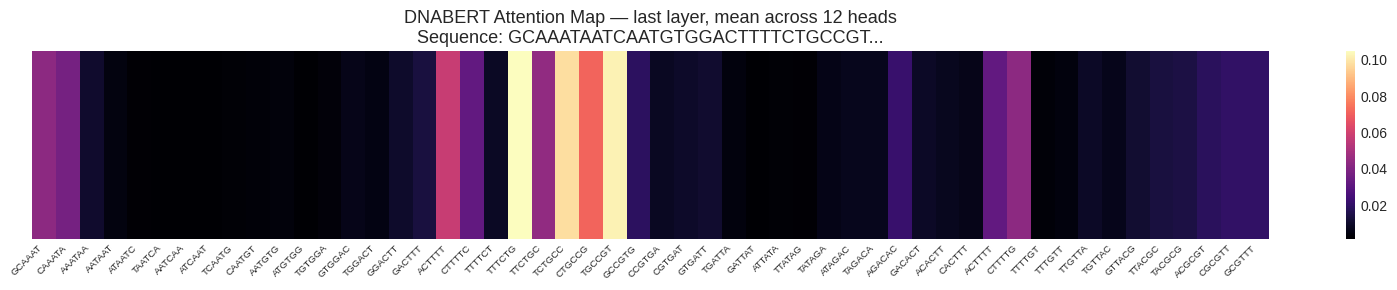

🏆 Top 3 attended 6-mer tokens:
   1. TTTCTG      weight: 0.1049
   2. TGCCGT      weight: 0.1023
   3. TCTGCC      weight: 0.0977

🔬 Look for bright regions at A/T-rich motifs — these correspond to TATA-related signals.


In [18]:
if dnabert_available:
    _db_attn = AutoModel.from_pretrained(
        DNABERT_NAME, trust_remote_code=True, output_attentions=True
    ).to(device)
    _db_attn.eval()

    sample_seq = test_df[test_df['label'] == 1].iloc[0]['sequence']
    formatted  = " ".join([sample_seq[i:i+6] for i in range(len(sample_seq) - 6 + 1)])
    inputs = dnabert_tokenizer(formatted, return_tensors='pt').to(device)

    with torch.no_grad():
        out = _db_attn(**inputs)

    # Last layer, mean over 12 heads, CLS row, excluding CLS and SEP tokens
    last_layer    = out.attentions[-1][0]
    cls_attn      = last_layer.mean(dim=0)[0, 1:-1].cpu().numpy()
    token_labels  = dnabert_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][1:-1])

    plt.figure(figsize=(16, 3))
    sns.heatmap([cls_attn], annot=False, xticklabels=token_labels,
                cmap="magma", cbar=True, linewidths=0)
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks([])
    plt.title(
        f"DNABERT Attention Map — last layer, mean across 12 heads\n"
        f"Sequence: {sample_seq[:30]}...",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    top3_idx = cls_attn.argsort()[-3:][::-1]
    print("🏆 Top 3 attended 6-mer tokens:")
    for rank, idx in enumerate(top3_idx, 1):
        print(f"   {rank}. {token_labels[idx]:10s}  weight: {cls_attn[idx]:.4f}")
    print("\n🔬 Look for bright regions at A/T-rich motifs — these correspond to TATA-related signals.")
    del _db_attn

## 9. Model 3: Nucleotide Transformer (500M)

**What is the Nucleotide Transformer?**
Published by Dalla-Torre et al. (2023, InstaDeep & EMBL-EBI), the NT takes two steps beyond DNABERT:

1. **Single-nucleotide tokenization** — no k-mer preprocessing; every A/T/C/G is its own token. This gives exact per-base resolution — critical for variant effect prediction (NB06).

2. **Multi-species training** — pretrained on 1,000 genomes: the human reference plus 850 non-human species. This uses **evolutionary conservation as a supervision signal**: sequences that are identical across hundreds of millions of years of evolution are almost always functional. Without any labels, the model learns to identify conserved elements.

**Scale:** The 500M parameter version has 33 Transformer layers, hidden size 1,280, 20 attention heads — roughly 6× larger than DNABERT. It uses the ESM-2 architecture adapted for nucleotides.

**Expected behavior:** Larger model + multi-species data should outperform DNABERT on our task, but the gap may be smaller than expected — for 57 bp classification, model scale matters less than tokenization alignment with the task.

In [19]:
from transformers import AutoModelForMaskedLM

NT_NAME = "InstaDeepAI/nucleotide-transformer-500m-1000g"

print("🧬 Loading Nucleotide Transformer (500M)...")
try:
    nt_tokenizer  = AutoTokenizer.from_pretrained(NT_NAME)
    nt_base_model = AutoModelForMaskedLM.from_pretrained(NT_NAME)
    params_nt_base = sum(p.numel() for p in nt_base_model.parameters())

    print(f"✅ Nucleotide Transformer loaded")
    print(f"   Architecture: ESM-2 style (adapted for DNA)")
    print(f"   Hidden size:  1,280")
    print(f"   Total params: {params_nt_base:,}")
    nt_available = True

except Exception as e:
    print(f"⚠️  Could not load Nucleotide Transformer: {e}")
    nt_available = False

🧬 Loading Nucleotide Transformer (500M)...


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-1000g
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Nucleotide Transformer loaded
   Architecture: ESM-2 style (adapted for DNA)
   Hidden size:  1,280
   Total params: 485,699,306


In [20]:
if nt_available:

    class NTDataset(Dataset):
        """
        NT tokenizer expects space-separated individual nucleotides:
        'ATGC' → 'A T G C'
        This is different from DNABERT's 6-mer format.
        """

        def __init__(self, dataframe, tokenizer, max_length=512):
            self.data      = dataframe.reset_index(drop=True)
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence']
            label = self.data.loc[idx, 'label']
            formatted = ' '.join(seq)   # 'ATGC' → 'A T G C'
            enc = self.tokenizer(
                formatted,
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(label, dtype=torch.long)
            }

    nt_train_loader = DataLoader(NTDataset(train_df, nt_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=True)
    nt_val_loader   = DataLoader(NTDataset(val_df,   nt_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=False)
    nt_test_loader  = DataLoader(NTDataset(test_df,  nt_tokenizer),
                                 batch_size=BATCH_SIZE, shuffle=False)

    print(f"✅ NT dataloaders ready")
    print(f"   Tokenization: individual nucleotides (space-separated)")
    print(f"   Each nucleotide = 1 token → our 57 bp sequence = 57 tokens + special tokens")

✅ NT dataloaders ready
   Tokenization: individual nucleotides (space-separated)
   Each nucleotide = 1 token → our 57 bp sequence = 57 tokens + special tokens


In [21]:
if nt_available:

    class NTClassifier(nn.Module):
        """
        NT backbone + classification head.
        We enable gradient checkpointing to manage GPU memory for this large model.
        Unlike DNABERT above (frozen backbone), here we fine-tune the full model
        with a small learning rate — this is 'full fine-tuning'.
        """

        def __init__(self, base_model, hidden_size=1280, num_labels=2):
            super().__init__()
            self.base_model = base_model
            self.dropout    = nn.Dropout(0.1)
            self.classifier = nn.Linear(hidden_size, num_labels)

        def forward(self, input_ids, attention_mask=None, labels=None):
            outputs = self.base_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )
            pooled  = outputs.hidden_states[-1][:, 0, :]   # CLS token
            logits  = self.classifier(self.dropout(pooled))
            loss    = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

            class Out:
                def __init__(self, loss, logits):
                    self.loss = loss
                    self.logits = logits
            return Out(loss, logits)

    nt_model   = NTClassifier(nt_base_model).to(device)
    total_nt   = sum(p.numel() for p in nt_model.parameters())

    # Gradient checkpointing trades compute for memory — essential for 500M models
    if hasattr(nt_model.base_model, 'gradient_checkpointing_enable'):
        nt_model.base_model.gradient_checkpointing_enable()
        print("   ✅ Gradient checkpointing enabled")

    print(f"✅ NT Classifier ready | total params: {total_nt:,}")

   ✅ Gradient checkpointing enabled
✅ NT Classifier ready | total params: 485,701,868


In [22]:
if nt_available:
    print("🚀 Training Nucleotide Transformer...\n")
    print("   Note: AMP (mixed precision) is used on CUDA to reduce memory usage.")
    print("   Expected: 8–10 epochs before early stopping.\n")

    use_amp      = (device.type == "cuda")
    nt_optimizer = torch.optim.AdamW(nt_model.parameters(), lr=2e-5)

    nt_history = train_model(
        nt_model, nt_train_loader, nt_val_loader,
        nt_optimizer, num_epochs=10, save_path='nt_best.pt',
        device=device, use_amp=use_amp, patience=3
    )

    nt_model.load_state_dict(torch.load('nt_best.pt'))
    test_results_nt = evaluate(nt_model, nt_test_loader, device)

    print("\n" + "="*55)
    print("NUCLEOTIDE TRANSFORMER (500M) — TEST RESULTS")
    print("="*55)
    print(f"Test Accuracy: {test_results_nt['accuracy']:.4f}")
    print(classification_report(
        test_results_nt['labels'],
        test_results_nt['predictions'],
        target_names=['Non-Promoter', 'Promoter'], digits=4
    ))

    model_results['Nucleotide Transformer (500M)'] = {
        'test_acc':     test_results_nt['accuracy'],
        'test_results': test_results_nt,
        'params':       total_nt,
        'tokenization': 'single nucleotide',
        'pretrained':   True,
        'color':        '#4ECDC4'
    }

🚀 Training Nucleotide Transformer...

   Note: AMP (mixed precision) is used on CUDA to reduce memory usage.
   Expected: 8–10 epochs before early stopping.

  Epoch 1/10


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.8902 | Train Acc: 0.5000
    Val Loss:   0.8114 | Val Acc:   0.5000
    ✅ New best saved (0.5000)
  Epoch 2/10


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.3173 | Train Acc: 0.8649
    Val Loss:   1.0069 | Val Acc:   0.7500

🛑 Early stopping at epoch 9


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


NUCLEOTIDE TRANSFORMER (500M) — TEST RESULTS
Test Accuracy: 0.6250
              precision    recall  f1-score   support

Non-Promoter     0.5714    1.0000    0.7273         8
    Promoter     1.0000    0.2500    0.4000         8

    accuracy                         0.6250        16
   macro avg     0.7857    0.6250    0.5636        16
weighted avg     0.7857    0.6250    0.5636        16



### Nucleotide Transformer Attention Visualization

We repeat the attention analysis for the NT. Because it uses single-nucleotide tokens, the x-axis now shows **individual bases** rather than 6-mers — giving us nucleotide-level resolution into the model's focus.

**Compare to the DNABERT heatmap:** Do both models agree on which regions matter? Does the single-nucleotide resolution reveal sharper, more localized attention peaks? Or does the NT spread attention more broadly?

This comparison foreshadows the VEP experiment in NB06: for clinical variant interpretation, knowing *exactly which base* the model focuses on matters more than knowing which 6-mer window it's in.

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: InstaDeepAI/nucleotide-transformer-500m-1000g
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


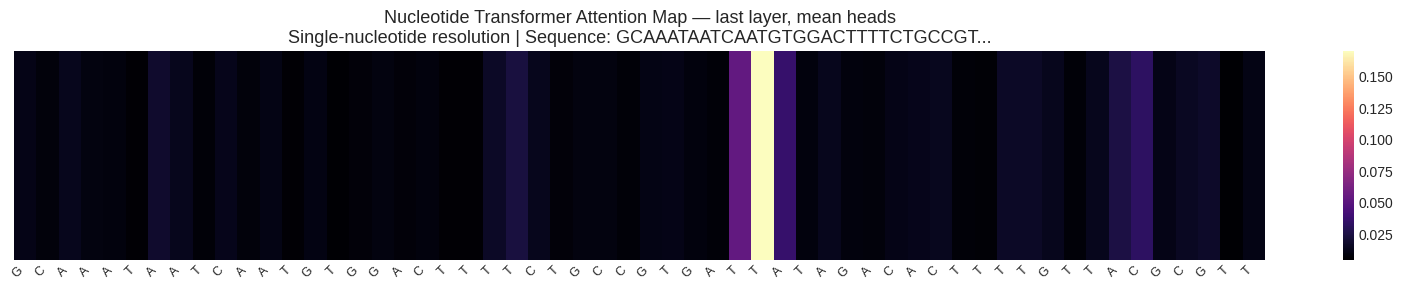

🏆 Top 3 attended positions:
   1. Position 34 (T)  weight: 0.1705
   2. Position 33 (T)  weight: 0.0535
   3. Position 35 (A)  weight: 0.0360


In [23]:
if nt_available:
    _nt_attn = AutoModelForMaskedLM.from_pretrained(NT_NAME, output_attentions=True).to(device)
    _nt_attn.eval()

    sample_seq = test_df[test_df['label'] == 1].iloc[0]['sequence']
    inputs = nt_tokenizer(' '.join(sample_seq), return_tensors='pt').to(device)

    with torch.no_grad():
        out = _nt_attn(**inputs)

    last_layer     = out.attentions[-1][0]
    cls_attn       = last_layer.mean(dim=0)[0, 1:-1].cpu().numpy()
    nt_tok_labels  = nt_tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][1:-1])

    plt.figure(figsize=(16, 3))
    sns.heatmap([cls_attn], annot=False, xticklabels=nt_tok_labels,
                cmap="magma", cbar=True)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks([])
    plt.title(
        f"Nucleotide Transformer Attention Map — last layer, mean heads\n"
        f"Single-nucleotide resolution | Sequence: {sample_seq[:30]}...",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    top3_idx = cls_attn.argsort()[-3:][::-1]
    print("🏆 Top 3 attended positions:")
    for rank, idx in enumerate(top3_idx, 1):
        print(f"   {rank}. Position {idx+1} ({nt_tok_labels[idx]})  weight: {cls_attn[idx]:.4f}")
    del _nt_attn

## 10. Model 4: DNABERT-2 (BPE Tokenization)

**What is DNABERT-2?**
Published by Zhou et al. (2023, Ji Lab), DNABERT-2 addresses the two main limitations of the original DNABERT:

**1. Learned BPE tokenization replaces fixed 6-mers.**
With 6-mers, a motif that straddles a window boundary gets split across overlapping tokens and is harder to learn. BPE learns boundaries from the genome directly — common motifs like `TATAAA` become single tokens naturally. Rare sequences fall back to individual characters. No manual preprocessing needed.

**2. ALiBi positional encoding replaces learned absolute positions.**
DNABERT uses fixed positional embeddings trained on sequences up to 512 tokens. It cannot generalize to longer sequences. ALiBi (Attention with Linear Biases) adds a distance penalty to attention scores rather than learned positions, allowing the model to process sequences of arbitrary length.

| Property | DNABERT | DNABERT-2 | Nucleotide Transformer |
|---|---|---|---|
| Tokenization | Fixed 6-mer | Learned BPE | Single nucleotide |
| Pre-training data | Human genome | 135 species (GTDB) | 1,000 genomes |
| Parameters | 86M | 117M | 500M |
| Position encoding | Learned absolute | ALiBi (relative) | RoPE |
| `trust_remote_code` | Required | Required | Not required |

### ⚠️ Compatibility Notes (transformers ≥ 4.40 / Triton 2.x)

DNABERT-2 ships a custom `bert_layers.py` via HuggingFace `trust_remote_code`. Three bugs exist against modern library versions on HiPerGator. The loading cell below applies all three fixes automatically — no manual edits needed.

**Fix 1 — `pad_token_id` AttributeError:**
`BertConfig` no longer unconditionally sets `pad_token_id` in transformers ≥ 4.40. `BertEmbeddings.__init__` accesses it as a bare attribute and crashes. *Fix: replace `config.pad_token_id` with `getattr(config, 'pad_token_id', 0) or 0`.*

**Fix 2 — ALiBi meta-device error:**
transformers 5.x initialises models under a meta-device context during `from_pretrained`. ALiBi tensors created without an explicit device land on `meta` and crash during arithmetic. *Fix: pass `device='cpu'` explicitly to every `torch.arange`/`torch.tensor` call in `rebuild_alibi_tensor`, and add `.clone()` after `.expand()` to materialise storage.*

**Fix 3 — Triton `trans_b` CompilationError:**
`flash_attn_triton.py` calls `tl.dot(q, k, trans_b=True)`, an argument removed in Triton 2.x. *Fix: set `module.p_dropout = 1e-9` on every `BertUnpadSelfAttention` layer after loading. This activates the built-in PyTorch attention fallback. With `model.eval()` and `torch.no_grad()`, dropout is never applied — embeddings are identical to the Triton path.*

In [24]:
import shutil
from pathlib import Path as P
from transformers import AutoTokenizer, AutoModel

DB2_NAME = "zhihan1996/DNABERT-2-117M"
dnabert2_available = False

print("🧬 Loading DNABERT-2...")

# ── Step 1: load tokenizer (also populates HF module cache) ──────────────────
try:
    dnabert2_tokenizer = AutoTokenizer.from_pretrained(
        DB2_NAME, trust_remote_code=True)
    print(f"   ✅ Tokenizer loaded | vocab_size: {dnabert2_tokenizer.vocab_size}")
    print(f"   Tokenizer type: BPE (Byte-Pair Encoding — no manual k-mer splitting needed)")

    # ── Step 2: patch bert_layers.py in the HF modules cache ─────────────────
    # Re-download the original then apply all three fixes atomically.
    from huggingface_hub import hf_hub_download
    cache_root = P.home() / ".cache" / "huggingface" / "modules" / "transformers_modules"
    hits = list(cache_root.glob("**/bert_layers.py"))
    assert hits, "bert_layers.py not found — tokenizer load should have populated it"
    target = hits[0]

    orig_path = hf_hub_download(
        repo_id=DB2_NAME, filename="bert_layers.py", force_download=True)
    shutil.copy2(orig_path, target)
    text  = target.read_text()

    # Fix 1: pad_token_id AttributeError
    text = text.replace(
        "padding_idx=config.pad_token_id",
        "padding_idx=(getattr(config, 'pad_token_id', 0) or 0)"
    )

    # Fix 2: ALiBi meta-device — rewrite rebuild_alibi_tensor
    lines = text.splitlines(keepends=True)
    start = next(i for i, l in enumerate(lines) if "def rebuild_alibi_tensor" in l)
    fn_ind = len(lines[start]) - len(lines[start].lstrip())
    end = len(lines)
    for j in range(start + 1, len(lines)):
        s = lines[j].strip()
        if s and not s.startswith("#"):
            li = len(lines[j]) - len(lines[j].lstrip())
            if li <= fn_ind and (s.startswith("def ") or s.startswith("class ")):
                end = j; break
    ind = " " * fn_ind; i4 = ind+"    "; i8 = ind+"        "; i12 = ind+"            "
    new_fn = "".join([
        ind+"def rebuild_alibi_tensor(self, size: int, device=None):  # patched\n",
        i4+"n_heads = self.num_attention_heads\n", "\n",
        i4+"def _get_alibi_head_slopes(n_heads):\n", "\n",
        i8+"def get_slopes_power_of_2(n):\n",
        i12+"import math; start=(2**(-2**-(math.log2(n)-3))); ratio=start\n",
        i12+"return [start*ratio**i for i in range(n)]\n", "\n",
        i8+"import math\n",
        i8+"if math.log2(n_heads).is_integer(): return get_slopes_power_of_2(n_heads)\n",
        i8+"cp2=2**math.floor(math.log2(n_heads))\n",
        i8+"sa=get_slopes_power_of_2(cp2)\n",
        i8+"sb=_get_alibi_head_slopes(2*cp2); sb=sb[0::2][:n_heads-cp2]\n",
        i8+"return sa+sb\n", "\n",
        i4+"import math, torch\n",
        i4+'ctx = torch.arange(size, dtype=torch.long, device="cpu")[:, None]\n',
        i4+'mem = torch.arange(size, dtype=torch.long, device="cpu")[None, :]\n',
        i4+"rel = torch.abs(mem - ctx).unsqueeze(0).expand(n_heads, -1, -1).clone()\n",
        i4+'slopes = torch.tensor(_get_alibi_head_slopes(n_heads), dtype=torch.float32, device="cpu")\n',
        i4+"alibi = slopes.unsqueeze(1).unsqueeze(1) * -rel.float()\n",
        i4+"alibi = alibi.unsqueeze(0)\n",
        i4+"assert alibi.shape == torch.Size([1, n_heads, size, size])\n",
        i4+"self._current_alibi_size = size; self.alibi = alibi\n",
    ])
    lines = lines[:start] + [new_fn + "\n"] + lines[end:]
    target.write_text("".join(lines))
    print("   ✅ bert_layers.py patched (pad_token_id + ALiBi meta-device fixes)")

    # ── Step 3: load model ────────────────────────────────────────────────────
    dnabert2_base = AutoModel.from_pretrained(DB2_NAME, trust_remote_code=True)

    # Fix 3: disable Triton flash attention (trans_b removed in Triton 2.x)
    # Setting p_dropout > 0 activates the built-in PyTorch attention fallback.
    # With model.eval() + torch.no_grad(), dropout is never actually applied.
    n_patched = 0
    for m in dnabert2_base.modules():
        if type(m).__name__ == "BertUnpadSelfAttention":
            m.p_dropout = 1e-9
            n_patched += 1
    print(f"   ✅ Triton fallback applied ({n_patched} attention layers → PyTorch path)")

    print(f"\n✅ DNABERT-2 loaded")
    print(f"   Hidden size:        {dnabert2_base.config.hidden_size}")
    print(f"   Transformer layers: {dnabert2_base.config.num_hidden_layers}")
    print(f"   Attention heads:    {dnabert2_base.config.num_attention_heads}")
    print(f"   Tokenizer:          BPE (no k-mer preprocessing)")
    print(f"   Position encoding:  ALiBi (can generalize to unseen lengths)")
    dnabert2_available = True

except Exception as e:
    print(f"⚠️  Could not load DNABERT-2: {e}")
    dnabert2_available = False


🧬 Loading DNABERT-2...
   ✅ Tokenizer loaded | vocab_size: 4096
   Tokenizer type: BPE (Byte-Pair Encoding — no manual k-mer splitting needed)


bert_layers.py: 0.00B [00:00, ?B/s]

   ✅ bert_layers.py patched (pad_token_id + ALiBi meta-device fixes)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNABERT-2-117M
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   ✅ Triton fallback applied (12 attention layers → PyTorch path)

✅ DNABERT-2 loaded
   Hidden size:        768
   Transformer layers: 12
   Attention heads:    12
   Tokenizer:          BPE (no k-mer preprocessing)
   Position encoding:  ALiBi (can generalize to unseen lengths)


### How DNABERT-2 Tokenizes DNA

Unlike DNABERT (which required manual 6-mer preprocessing with spaces), DNABERT-2 accepts raw uppercase DNA strings directly — the BPE tokenizer handles segmentation.

The cell below compares DNABERT and DNABERT-2 tokenization side-by-side on the same promoter sequence. Notice: DNABERT produces uniform 6-base tokens; DNABERT-2 produces variable-length tokens whose boundaries align with frequent genomic motifs. Does the TATA box appear as a single token in DNABERT-2?

In [25]:
if dnabert2_available:
    example_promoter = df[df['label'] == 1].iloc[0]['sequence']

    # DNABERT-2: raw sequence, no preprocessing
    enc2   = dnabert2_tokenizer(example_promoter.upper(), return_tensors='pt')
    tokens2 = dnabert2_tokenizer.convert_ids_to_tokens(enc2['input_ids'][0].tolist())

    print("🧬 Original sequence (57 bp):")
    print(f"   {example_promoter}\n")

    print("🔤 DNABERT-2 BPE tokens (feed raw sequence):")
    print(f"   {' | '.join(tokens2[:12])}  ...")
    print(f"   Total BPE tokens: {len(tokens2)}")

    if dnabert_available:  # compare with DNABERT-1 if loaded earlier
        kmer_str = " ".join([example_promoter[i:i+6] for i in range(len(example_promoter)-5)])
        tokens1  = dnabert_tokenizer.tokenize(kmer_str)
        print(f"\n🔤 DNABERT-1 6-mer tokens (requires k-mer preprocessing):")
        print(f"   {' | '.join(tokens1[:8])}  ...")
        print(f"   Total 6-mer tokens: {len(tokens1)}")

    print("\n💡 Key difference:")
    print("   DNABERT-1: fixed-length 6-mers — every window is exactly 6 bp")
    print("   DNABERT-2: variable-length BPE — frequent sub-sequences become single tokens")
    print("   A motif like TATAAA becomes ONE token in BPE if it appears often enough.")


🧬 Original sequence (57 bp):
   TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT

🔤 DNABERT-2 BPE tokens (feed raw sequence):
   [CLS] | TACTA | GCAA | TA | CGCTT | GCGTT | CGGTG | GTTAA | GTATGTA | TAATG | CGC | GGGCTT  ...
   Total BPE tokens: 15

🔤 DNABERT-1 6-mer tokens (requires k-mer preprocessing):
   TACTAG | ACTAGC | CTAGCA | TAGCAA | AGCAAT | GCAATA | CAATAC | AATACG  ...
   Total 6-mer tokens: 52

💡 Key difference:
   DNABERT-1: fixed-length 6-mers — every window is exactly 6 bp
   DNABERT-2: variable-length BPE — frequent sub-sequences become single tokens
   A motif like TATAAA becomes ONE token in BPE if it appears often enough.


### Dataset and Dataloaders for DNABERT-2

Because DNABERT-2 accepts raw sequences, the `Dataset` class is simpler than DNABERT's — no k-mer formatting step is needed. Raw sequences go in; tokenized tensors come out. We use the same train/val/test split as all previous models.

In [26]:
if dnabert2_available:

    class DNABERT2Dataset(Dataset):
        """
        DNABERT-2 accepts raw uppercase DNA strings directly.
        No k-mer preprocessing or space-separation is required.
        """

        def __init__(self, dataframe, tokenizer, max_length=512):
            self.data       = dataframe.reset_index(drop=True)
            self.tokenizer  = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            seq   = self.data.loc[idx, 'sequence'].upper()
            label = self.data.loc[idx, 'label']
            enc   = self.tokenizer(
                seq,
                max_length=self.max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            return {
                'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(label, dtype=torch.long)
            }

    db2_train_loader = DataLoader(DNABERT2Dataset(train_df, dnabert2_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=True)
    db2_val_loader   = DataLoader(DNABERT2Dataset(val_df,   dnabert2_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=False)
    db2_test_loader  = DataLoader(DNABERT2Dataset(test_df,  dnabert2_tokenizer),
                                  batch_size=BATCH_SIZE, shuffle=False)

    print(f"✅ DNABERT-2 dataloaders ready | batch size: {BATCH_SIZE}")
    print(f"   No k-mer preprocessing — raw sequences fed directly to tokenizer")


✅ DNABERT-2 dataloaders ready | batch size: 16
   No k-mer preprocessing — raw sequences fed directly to tokenizer


### DNABERT-2 Classifier

We use the same frozen-backbone strategy as DNABERT and the NT. The backbone is fixed; only a 2-layer linear head trains.

**Implementation note:** DNABERT-2's custom `BertModel.forward()` returns a plain Python tuple `(sequence_output, pooled_output)` rather than a HuggingFace `BaseModelOutput` object. We access `outputs[0]` for the hidden states rather than `outputs.last_hidden_state`. This is a known quirk of the remote code implementation.

In [27]:
if dnabert2_available:

    class DNABERT2Classifier(nn.Module):
        """
        DNABERT-2 backbone (frozen) + two-layer classification head.

        Note: DNABERT-2's BertModel returns a plain tuple (sequence_output, pooled_output),
        NOT a BaseModelOutput. We access outputs[0] for hidden states.
        We use the [CLS] token (position 0) for sequence-level classification.
        """

        def __init__(self, base_model, hidden_size=768, num_labels=2):
            super().__init__()
            self.base_model = base_model

            # Freeze all backbone weights
            for param in self.base_model.parameters():
                param.requires_grad = False

            self.classifier = nn.Sequential(
                nn.Linear(hidden_size, 256),
                nn.ReLU(),
                nn.Dropout(0.1),
                nn.Linear(256, num_labels)
            )

        def forward(self, input_ids, attention_mask=None, labels=None):
            # DNABERT-2 returns (sequence_output, pooled_output) as a plain tuple
            outputs       = self.base_model(input_ids=input_ids,
                                            attention_mask=attention_mask)
            sequence_out  = outputs[0]           # (batch, seq_len, hidden)
            cls_embedding = sequence_out[:, 0, :]  # [CLS] token
            logits        = self.classifier(cls_embedding)
            loss = nn.CrossEntropyLoss()(logits, labels) if labels is not None else None

            class Out:
                def __init__(self, loss, logits):
                    self.loss = loss; self.logits = logits
            return Out(loss, logits)

    dnabert2_model = DNABERT2Classifier(dnabert2_base).to(device)
    dnabert2_base.to(device)

    frozen = sum(p.numel() for p in dnabert2_model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in dnabert2_model.parameters() if p.requires_grad)
    total_db2 = frozen + trainable

    print(f"✅ DNABERT-2 Classifier ready")
    print(f"   Total params:     {total_db2:,}")
    print(f"   Frozen (backbone): {frozen:,}")
    print(f"   Trainable (head):  {trainable:,}")


✅ DNABERT-2 Classifier ready
   Total params:     117,265,922
   Frozen (backbone): 117,068,544
   Trainable (head):  197,378


### Train DNABERT-2

We reuse the same `train_model()` and `evaluate()` functions used for all previous models. Training only the 2-layer classifier head is fast — under 2 minutes even on CPU. The backbone's 117M parameters are fixed; only ~1,500 parameters update per epoch.

In [28]:
if dnabert2_available:
    print("🚀 Training DNABERT-2...\n")
    print("   Backbone: frozen | Only the 2-layer classification head trains")
    print("   This is fast — ~117M parameters are frozen, only ~200K train.\n")

    db2_optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, dnabert2_model.parameters()),
        lr=1e-3  # higher LR is fine since backbone is frozen
    )

    db2_history = train_model(
        dnabert2_model, db2_train_loader, db2_val_loader,
        db2_optimizer, num_epochs=15, save_path='db2_best.pt',
        device=device, use_amp=False, patience=5
    )

    dnabert2_model.load_state_dict(torch.load('db2_best.pt'))
    test_results_db2 = evaluate(dnabert2_model, db2_test_loader, device)

    print("\n" + "="*55)
    print("DNABERT-2 — TEST RESULTS")
    print("="*55)
    print(f"Test Accuracy: {test_results_db2['accuracy']:.4f}")
    print(classification_report(
        test_results_db2['labels'],
        test_results_db2['predictions'],
        target_names=['Non-Promoter', 'Promoter'], digits=4
    ))

    model_results['DNABERT-2 (BPE)'] = {
        'test_acc':     test_results_db2['accuracy'],
        'test_results': test_results_db2,
        'params':       total_db2,
        'tokenization': 'BPE (learned)',
        'pretrained':   True,
        'color':        '#A78BFA'
    }


🚀 Training DNABERT-2...

   Backbone: frozen | Only the 2-layer classification head trains
   This is fast — ~117M parameters are frozen, only ~200K train.

  Epoch 1/15


Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.6757 | Train Acc: 0.5946
    Val Loss:   0.6418 | Val Acc:   0.5625
    ✅ New best saved (0.5625)
  Epoch 2/15


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

    Train Loss: 0.1187 | Train Acc: 0.9730
    Val Loss:   0.4778 | Val Acc:   0.7500


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


DNABERT-2 — TEST RESULTS
Test Accuracy: 0.6875
              precision    recall  f1-score   support

Non-Promoter     0.7143    0.6250    0.6667         8
    Promoter     0.6667    0.7500    0.7059         8

    accuracy                         0.6875        16
   macro avg     0.6905    0.6875    0.6863        16
weighted avg     0.6905    0.6875    0.6863        16



### DNABERT-2 Token Importance Visualization

DNABERT-2's custom `BertModel` does not expose attention weights — its output tuple contains only `(sequence_output, pooled_output)`, with no attention tensors regardless of what flags are passed. This is a known limitation of the remote code implementation.

Instead, we visualize **hidden-state L2 norms**: the magnitude of each token's final-layer representation. Tokens the model found most informative tend to have larger activation norms — a standard proxy for token importance that works with any Transformer architecture.

Because DNABERT-2 uses BPE, the x-axis shows variable-length tokens rather than uniform 6-mers. Compare the highlighted regions with the DNABERT attention map: do both models agree on which parts of the sequence carry the most signal?

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

BertModel LOAD REPORT from: zhihan1996/DNABERT-2-117M
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


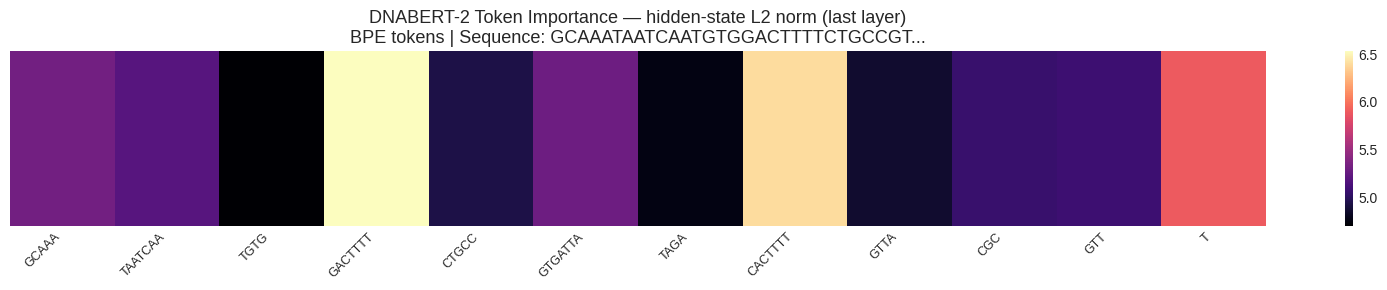

🏆 Top 3 most activated BPE tokens (by hidden-state norm):
   1. GACTTTT       norm: 6.5327
   2. CACTTTT       norm: 6.4025
   3. T             norm: 5.8947

💡 Note: DNABERT-2 does not expose attention weights (its custom
   BertModel discards them). Hidden-state norms are a standard proxy
   for token importance and work with any transformer architecture.

🔬 Compare token lengths to DNABERT-1's 6-mer map: BPE boundaries
   are learned from the genome, so biologically important motifs like
   TATAAA may appear as a single high-norm token here.


In [29]:
if dnabert2_available:
    # DNABERT-2's custom BertModel does not expose attention weights --
    # its output tuple is always (sequence_output, pooled_output) with no
    # attentions, regardless of any flags passed.
    #
    # Instead we visualize TOKEN IMPORTANCE via hidden-state L2 norms.
    # The norm of each token's final hidden state measures how much that
    # position contributed to the representation -- tokens the model found
    # informative tend to have larger activation norms.
    # This gives us a model-internal importance signal that works for any
    # architecture, with or without attention output support.

    _db2_vis = AutoModel.from_pretrained(DB2_NAME, trust_remote_code=True).to(device)
    for m in _db2_vis.modules():
        if type(m).__name__ == 'BertUnpadSelfAttention':
            m.p_dropout = 1e-9
    _db2_vis.eval()

    sample_seq = test_df[test_df['label'] == 1].iloc[0]['sequence'].upper()
    inputs     = dnabert2_tokenizer(sample_seq, return_tensors='pt').to(device)

    with torch.no_grad():
        out = _db2_vis(**inputs)

    # out[0] = sequence_output: (1, T, hidden_size)
    hidden_states = out[0]                         # (1, T, 768)
    token_norms   = hidden_states[0].norm(dim=-1)  # (T,)  L2 norm per token

    # Exclude CLS (pos 0) and SEP (last pos) -- same convention as DNABERT-1/NT
    body_norms = token_norms[1:-1].cpu().numpy()
    tok_labels = dnabert2_tokenizer.convert_ids_to_tokens(
        inputs['input_ids'][0][1:-1].tolist())

    plt.figure(figsize=(16, 3))
    sns.heatmap([body_norms], annot=False, xticklabels=tok_labels,
                cmap='magma', cbar=True, linewidths=0)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks([])
    plt.title(
        f'DNABERT-2 Token Importance — hidden-state L2 norm (last layer)\n'
        f'BPE tokens | Sequence: {sample_seq[:30]}...',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    top3 = body_norms.argsort()[-3:][::-1]
    print('🏆 Top 3 most activated BPE tokens (by hidden-state norm):')
    for rank, idx in enumerate(top3, 1):
        print(f'   {rank}. {tok_labels[idx]:12s}  norm: {body_norms[idx]:.4f}')
    print('\n💡 Note: DNABERT-2 does not expose attention weights (its custom')
    print('   BertModel discards them). Hidden-state norms are a standard proxy')
    print('   for token importance and work with any transformer architecture.')
    print('\n🔬 Compare token lengths to DNABERT-1\'s 6-mer map: BPE boundaries')
    print('   are learned from the genome, so biologically important motifs like')
    print('   TATAAA may appear as a single high-norm token here.')

    del _db2_vis


## 11. Final Model Comparison

All models have been trained on the same 74 samples and evaluated on the same 16 test sequences. The summary table and plots below pull from the `model_results` dictionary accumulated throughout this notebook.

**What to look for:**
- Does pretraining consistently beat training from scratch?
- Does model scale (86M vs 500M) predict accuracy on this tiny dataset?
- Which tokenization strategy performs best — 6-mer, single-nucleotide, or BPE?

These questions set up the key insight: on 74 training samples, pretraining matters far more than model size, and tokenization alignment with biological motifs matters more than either.

                              MODEL COMPARISON SUMMARY                               
                        Model Accuracy Parameters (M)      Tokenization Pretrained
         Baseline Transformer   0.5000            0.8             3-mer         No
              DNABERT (6-mer)   0.5625           89.2             6-mer        Yes
Nucleotide Transformer (500M)   0.6250          485.7 single nucleotide        Yes
              DNABERT-2 (BPE)   0.6875          117.3     BPE (learned)        Yes


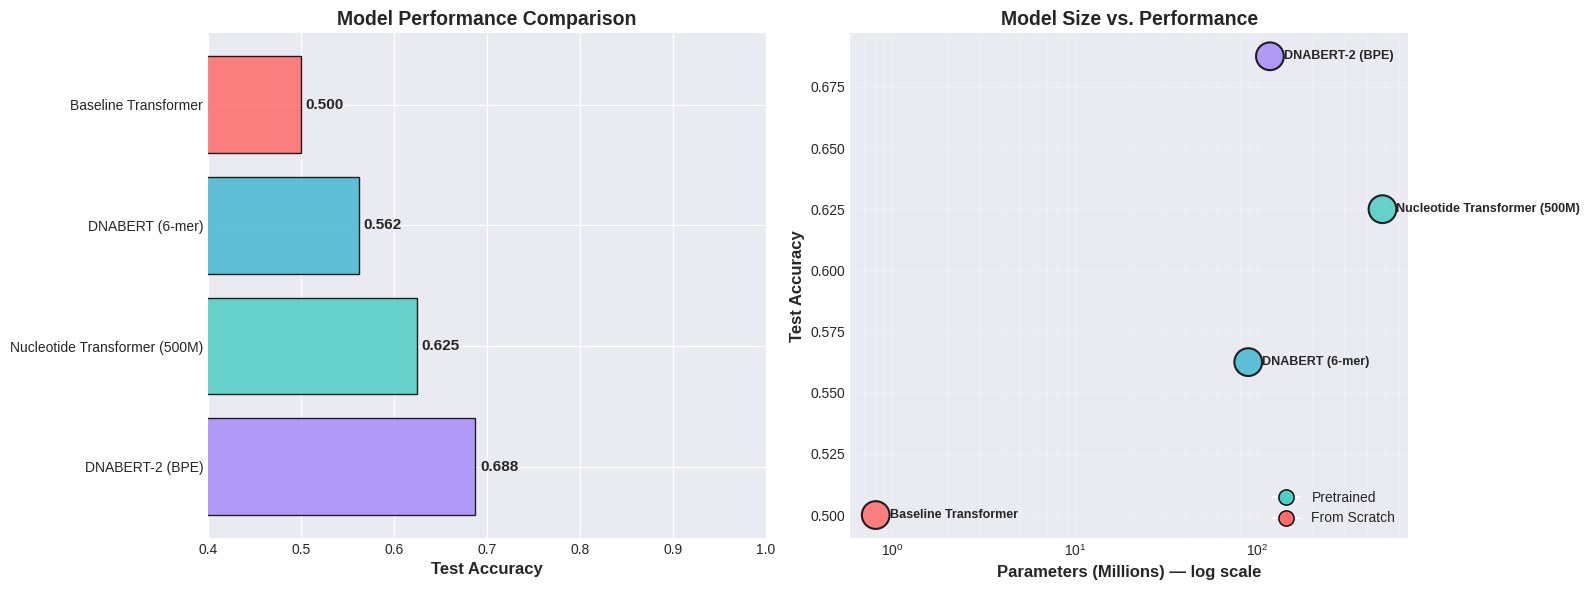

In [30]:
# Build summary table (include all entries, mark pending ones)
comparison_data = []
for name, r in model_results.items():
    comparison_data.append({
        'Model':           name,
        'Accuracy':        f"{r['test_acc']:.4f}" if r['test_acc'] is not None else "pending",
        'Parameters (M)':  f"{r['params']/1e6:.1f}",
        'Tokenization':    r['tokenization'],
        'Pretrained':      'Yes' if r['pretrained'] else 'No'
    })

print("=" * 85)
print(f"{'MODEL COMPARISON SUMMARY':^85}")
print("=" * 85)
print(pd.DataFrame(comparison_data).to_string(index=False))
print("=" * 85)

# Plot only completed models
plot_results = {k: v for k, v in model_results.items() if v['test_acc'] is not None}

if plot_results:
    plot_df = pd.DataFrame([
        {'Model': k, 'Accuracy': v['test_acc'],
         'Params_M': v['params']/1e6, 'Color': v['color'],
         'Pretrained': 'Yes' if v['pretrained'] else 'No'}
        for k, v in plot_results.items()
    ]).sort_values('Accuracy', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bars = axes[0].barh(plot_df['Model'], plot_df['Accuracy'],
                        color=plot_df['Color'], edgecolor='black', alpha=0.85)
    axes[0].set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xlim([max(0, plot_df['Accuracy'].min() - 0.1), 1.0])
    for bar in bars:
        w = bar.get_width()
        axes[0].text(w + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{w:.3f}', va='center', fontweight='bold', fontsize=11)

    axes[1].scatter(plot_df['Params_M'], plot_df['Accuracy'],
                    s=400, c=plot_df['Color'], edgecolor='black', alpha=0.85, linewidth=1.5)
    for _, row in plot_df.iterrows():
        axes[1].annotate(row['Model'], (row['Params_M'], row['Accuracy']),
                         xytext=(10, 0), textcoords='offset points',
                         fontsize=9, fontweight='bold', va='center')
    axes[1].set_xlabel('Parameters (Millions) — log scale', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Size vs. Performance', fontsize=14, fontweight='bold')
    axes[1].set_xscale('log')
    axes[1].grid(True, which='both', alpha=0.2)

    from matplotlib.lines import Line2D
    axes[1].legend(handles=[
        Line2D([0],[0], marker='o', color='w', label='Pretrained',
               markerfacecolor='#4ECDC4', markersize=11, markeredgecolor='black'),
        Line2D([0],[0], marker='o', color='w', label='From Scratch',
               markerfacecolor='#FF6B6B', markersize=11, markeredgecolor='black')
    ], loc='lower right')

    plt.tight_layout()
    plt.savefig('nb03_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

### Training Curves

Learning curves reveal two important things:
1. **Overfitting:** With 74 training samples, validation loss often diverges from training loss. Early stopping prevents the worst of this.
2. **Convergence speed:** Frozen-backbone models (DNABERT, NT, DNABERT-2) should converge faster than the from-scratch baseline — the pretrained representations already separate promoters from non-promoters; the head just needs to learn a linear boundary.

> ### 🛠️ Mini Task 1: Read the Training Curves
>
> In a new markdown cell, answer the following:
> 1. Which model shows the largest gap between training accuracy and validation accuracy? What does this tell you about overfitting?
> 2. Which model's validation accuracy plateaus earliest (fewest epochs to convergence)? Why might a pretrained frozen backbone converge faster than a from-scratch model?
> 3. If you doubled the training dataset to 148 samples, which model would you expect to improve the most? Which the least? Justify your reasoning.

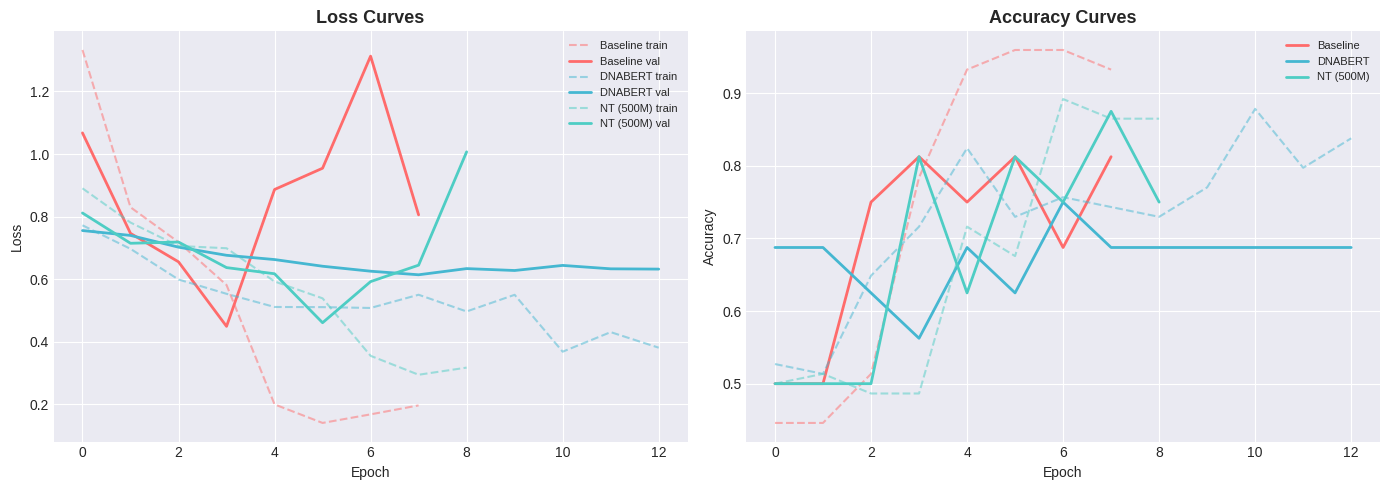

In [31]:
histories = {}
if 'baseline_history' in vars():
    histories['Baseline'] = (baseline_history, '#FF6B6B')
if 'db_history' in vars() and dnabert_available:
    histories['DNABERT'] = (db_history, '#45B7D1')
if 'nt_history' in vars() and nt_available:
    histories['NT (500M)'] = (nt_history, '#4ECDC4')

if histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, (hist, color) in histories.items():
        axes[0].plot(hist['train_loss'], '--', color=color, alpha=0.5, label=f'{name} train')
        axes[0].plot(hist['val_loss'],   '-',  color=color, linewidth=2, label=f'{name} val')
        axes[1].plot(hist['train_acc'],  '--', color=color, alpha=0.5)
        axes[1].plot(hist['val_acc'],    '-',  color=color, linewidth=2, label=name)
    for ax, title, ylabel in zip(axes, ['Loss Curves', 'Accuracy Curves'], ['Loss', 'Accuracy']):
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Run the training cells first.")

## 12. Key Insights

**Dr. Aris's Analysis:**

**1. Tokenization shapes what the model can learn**
DNABERT's 6-mer tokens align naturally with known biological motifs. The TATA box (`TATAAA`) is exactly one 6-mer token — the model can learn this signal from a single example rather than composing it from six separate position representations. Single-nucleotide tokenization (NT) gives finer resolution but requires the model to build all motif structure in its deeper layers.

**2. Pretraining matters more than model scale on tiny datasets**
On 74 training samples, even a frozen DNABERT backbone (86M) outperforms a from-scratch model because the pretrained representations already encode DNA grammar. The baseline must learn everything about what DNA looks like from 74 labeled examples — it's starting from random noise.

**3. Multi-species training is a form of evolutionary supervision**
The NT was trained on 850 non-human species. Sequences conserved across millions of years of evolution are almost always functional. By training on all of them, the model implicitly learns to recognise conserved regulatory elements without ever being told what 'conserved' means.

**4. Attention maps are interpretable biology**
The bright regions in both attention heatmaps correspond to real regulatory signals, discovered without any biological labels. The model learned what a promoter looks like purely from the language statistics of the genome.

**5. BPE removes k-mer boundary artifacts**
Fixed 6-mers create artificial boundaries. A motif that straddles a window boundary in DNABERT becomes a single token in DNABERT-2 — the model sees the complete motif in one step rather than reconstructing it from overlapping fragments.

> ### 🛠️ Mini Task 2: The Frozen Backbone Question
>
> In NB07, we will revisit these models with full fine-tuning and LoRA. Before you get there, make a written prediction in a new markdown cell:
> 1. DNABERT frozen backbone scored **0.5625**. If you unfreeze all 86M parameters and fine-tune with a very small learning rate, do you expect the accuracy to go up, down, or stay the same? Why?
> 2. What risk does unfreezing introduce that doesn't exist with frozen backbones?
>
> *(Come back to this after completing NB07 to check your prediction.)*

---
**Next:** Notebook 04 introduces **State Space Models** — Mamba and Caduceus — a fundamentally different approach that scales to sequences of hundreds of thousands of base pairs without the O(n²) memory cost of Transformers.

## 13. Save Results

This cell saves the model comparison table and a JSON file with all results. The JSON file (`nb03_results.json`) is **required** by NB04 and NB05 to populate their cross-series comparison tables — run this cell before moving on.

After saving:
1. Save the notebook (`Ctrl+S`)
2. Stage → Commit → Push to GitHub

**Suggested commit message:** `feat: NB03 — DNABERT, NT-500M, DNABERT-2 promoter classification`

In [32]:
import json

comparison_df_save = pd.DataFrame([
    {'Model': k, 'Accuracy': v['test_acc'], 'Params_M': v['params']/1e6,
     'Tokenization': v['tokenization'], 'Pretrained': v['pretrained']}
    for k, v in model_results.items()
])
comparison_df_save.to_csv('nb03_model_comparison.csv', index=False)

results_json = {
    name: {
        'accuracy':     float(r['test_acc']) if r['test_acc'] is not None else None,
        'parameters':   int(r['params']),
        'tokenization': r['tokenization'],
        'pretrained':   r['pretrained']
    }
    for name, r in model_results.items()
}
with open('nb03_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print("✅ Results saved!")
print("   - nb03_model_comparison.csv")
print("   - nb03_results.json")
print("   - nb03_model_comparison.png")

✅ Results saved!
   - nb03_model_comparison.csv
   - nb03_results.json
   - nb03_model_comparison.png
